In [2]:
import random
import os

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from datasets import load_dataset

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from tqdm import tqdm

In [19]:
IMAGE_SIZE         = 128
MAX_SAMPLES        = 5000
BATCH_SIZE_UPLOAD  = 500

SAVE_ROOT          = "generated_watermark_dataset"
WATERMARKED_DIR    = os.path.join(SAVE_ROOT, "watermarked")
CLEAN_DIR          = os.path.join(SAVE_ROOT, "clean")
TEMP_BATCH_DIR     = "upload_batch_temp"

REPO_ID            = "GeraldNdawula/Watermark_Dataset"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [20]:
def add_synthetic_watermark(image):
    image = image.copy().convert("RGB")
    width, height = image.size
    watermark_layer = Image.new("RGBA", image.size, (0, 0, 0, 0))

    text_options       = ["PROOF", "Lifetouch", "PREVIEW", "PHOTO PROOF",
                          "DO NOT COPY", "GRAD PHOTO", "SENIOR PORTRAIT"]
    small_text_options = ["PROOF IMAGE", "STUDIO PROOF", "PREVIEW ONLY",
                          "DO NOT COPY", "PHOTO STUDIO"]

    main_text  = random.choice(text_options)
    small_text = random.choice(small_text_options)

    font_size_main  = random.randint(35, 50)
    font_size_small = random.randint(20, 35)

    try:
        main_font  = ImageFont.truetype("arial.ttf", font_size_main)
        small_font = ImageFont.truetype("arial.ttf", font_size_small)
    except:
        main_font  = ImageFont.load_default()
        small_font = ImageFont.load_default()

    main_opacity  = random.randint(180, 250)
    small_opacity = min(random.randint(250, 350), 255)  # clamp to valid alpha

    color_choices = [
        (255, 255, 255, main_opacity), (220, 220, 220, main_opacity),
        (160, 160, 160, main_opacity), (40,  40,  40,  main_opacity)
    ]
    small_color_choices = [
        (255, 255, 255, small_opacity), (200, 200, 200, small_opacity),
        (40,  40,  40,  small_opacity)
    ]

    main_color  = random.choice(color_choices)
    small_color = random.choice(small_color_choices)

    def make_tile(angle=0):
        tile_w = random.randint(170, 280)
        tile_h = random.randint(70, 115)
        tile   = Image.new("RGBA", (tile_w, tile_h), (0, 0, 0, 0))
        draw   = ImageDraw.Draw(tile)
        if random.random() < 0.6:
            shadow_color = (0, 0, 0, int(main_opacity * 0.55))
            draw.text((13, 25), main_text, font=main_font, fill=shadow_color)
        draw.text((10, 6),  small_text, font=small_font, fill=small_color)
        draw.text((10, 22), main_text,  font=main_font,  fill=main_color)
        return tile.rotate(angle, expand=True)

    def paste_repeated(angle, step_x=None, step_y=None):
        tile = make_tile(angle)
        rw, rh = tile.size
        if step_x is None: step_x = random.randint(85, 135)
        if step_y is None: step_y = random.randint(65, 115)
        for y in range(-rh, height + rh, step_y):
            for x in range(-rw, width + rw, step_x):
                watermark_layer.alpha_composite(
                    tile,
                    (x + random.randint(-10, 10), y + random.randint(-10, 10))
                )

    def paste_center_stamp():
        stamp = make_tile(angle=random.choice([-8, 0, 8]))
        stamp = stamp.resize((min(width, stamp.width + 40), min(height, stamp.height + 20)))
        x = random.randint(0, max(1, width  - stamp.width))
        y = random.randint(0, max(1, height - stamp.height))
        watermark_layer.alpha_composite(stamp, (x, y))

    pattern_type = random.choice([
        "diagonal", "vertical", "horizontal", "grid", "center",
        "mixed_diagonal_vertical", "mixed_grid_center", "mixed_all"
    ])

    if   pattern_type == "diagonal":                paste_repeated(random.choice([-30,-25,-20,20,25,30]))
    elif pattern_type == "vertical":                paste_repeated(90, step_x=random.randint(70,110),  step_y=random.randint(100,160))
    elif pattern_type == "horizontal":              paste_repeated(0,  step_x=random.randint(100,160), step_y=random.randint(55,95))
    elif pattern_type == "grid":                    paste_repeated(0);  paste_repeated(90, step_x=random.randint(80,130), step_y=random.randint(110,170))
    elif pattern_type == "center":                  paste_center_stamp()
    elif pattern_type == "mixed_diagonal_vertical": paste_repeated(random.choice([-30,-25,25,30]));  paste_repeated(90, step_x=random.randint(75,120), step_y=random.randint(100,160))
    elif pattern_type == "mixed_grid_center":       paste_repeated(0);  paste_center_stamp()
    elif pattern_type == "mixed_all":
        paste_repeated(random.choice([-30,-25,25,30]))
        paste_repeated(90, step_x=random.randint(75,120), step_y=random.randint(100,160))
        paste_repeated(0,  step_x=random.randint(100,160), step_y=random.randint(55,95))
        if random.random() < 0.7: paste_center_stamp()

    combined = Image.alpha_composite(image.convert("RGBA"), watermark_layer)
    return combined.convert("RGB")

In [21]:
os.makedirs(WATERMARKED_DIR, exist_ok=True)
os.makedirs(CLEAN_DIR,       exist_ok=True)

resize = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))

hf_data = load_dataset("nielsr/CelebA-faces", split="train", streaming=True)

print(f"Generating {MAX_SAMPLES} pairs → {SAVE_ROOT}/")

for i, sample in enumerate(tqdm(hf_data, total=MAX_SAMPLES)):
    if i >= MAX_SAMPLES:
        break

    clean_img       = resize(sample["image"].convert("RGB"))
    watermarked_img = add_synthetic_watermark(clean_img)

    clean_img.save(      os.path.join(CLEAN_DIR,       f"clean_{i}.png"))
    watermarked_img.save(os.path.join(WATERMARKED_DIR, f"watermarked_{i}.png"))

print("Generation complete.")
print(f"  Clean:      {len(os.listdir(CLEAN_DIR))}")
print(f"  Watermarked: {len(os.listdir(WATERMARKED_DIR))}")

Generating 5000 pairs → generated_watermark_dataset/


100%|██████████| 5000/5000 [01:22<00:00, 60.71it/s]

Generation complete.
  Clean:      5000
  Watermarked: 5000


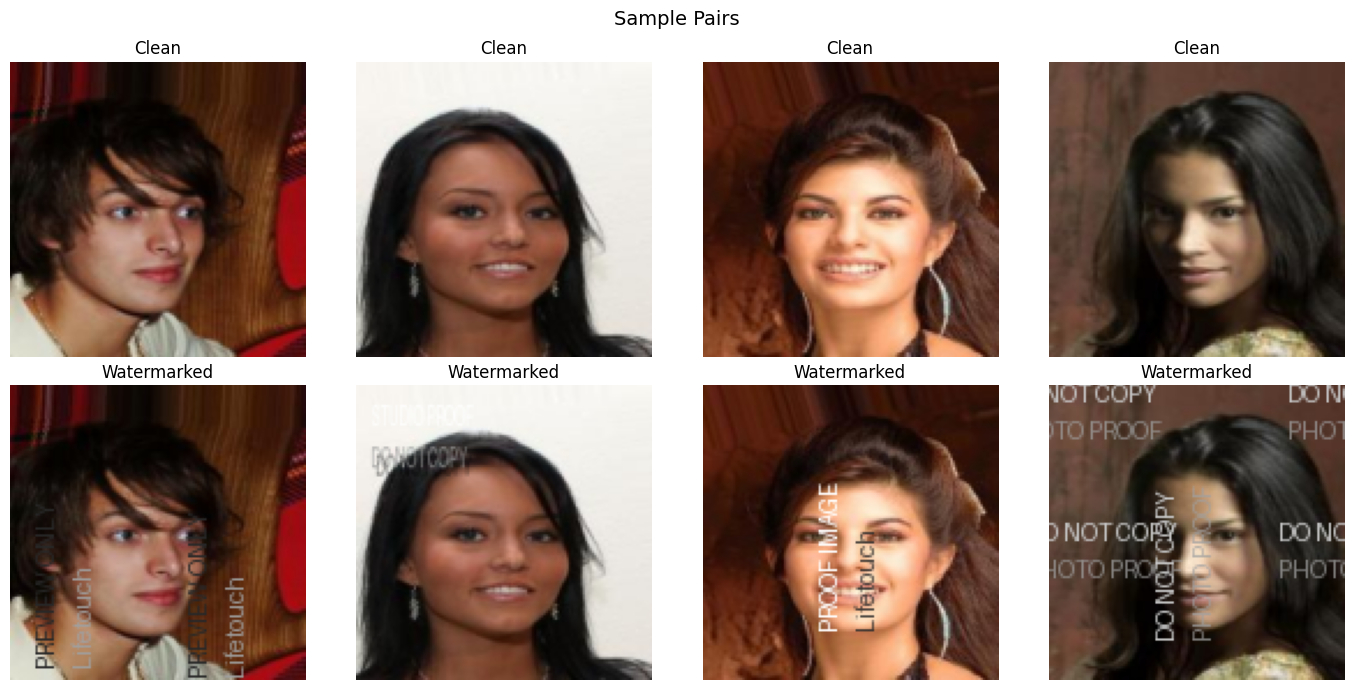

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i in range(4):
    clean_img       = Image.open(os.path.join(CLEAN_DIR,       f"clean_{i}.png"))
    watermarked_img = Image.open(os.path.join(WATERMARKED_DIR, f"watermarked_{i}.png"))

    axes[0][i].imshow(clean_img);       axes[0][i].set_title("Clean");       axes[0][i].axis("off")
    axes[1][i].imshow(watermarked_img); axes[1][i].set_title("Watermarked"); axes[1][i].axis("off")

plt.suptitle("Sample Pairs", fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
login()
api = HfApi()

# Wipe existing data/ in repo
print("Clearing existing repo data/ folder...")
try:
    existing = [f for f in api.list_repo_files(repo_id=REPO_ID, repo_type="dataset") if f.startswith("data/")]
    if existing:
        api.delete_files(
            repo_id=REPO_ID,
            repo_type="dataset",
            delete_patterns=["data/*"],
            commit_message="Clear old data before re-upload"
        )
        print(f"Deleted {len(existing)} existing files.")
    else:
        print("No existing data/ files found.")
except Exception as e:
    print(f"Warning: {e}")

watermarked_files = sorted(os.listdir(WATERMARKED_DIR))
clean_files       = sorted(os.listdir(CLEAN_DIR))
total_pairs       = min(len(watermarked_files), len(clean_files))
print(f"Total pairs: {total_pairs}")

def image_to_bytes(path):
    with open(path, "rb") as f:
        return f.read()

for start_idx in range(0, total_pairs, BATCH_SIZE_UPLOAD):
    end_idx = min(start_idx + BATCH_SIZE_UPLOAD, total_pairs)

    if os.path.exists(TEMP_BATCH_DIR):
        shutil.rmtree(TEMP_BATCH_DIR)
    os.makedirs(TEMP_BATCH_DIR)

    print(f"\nPreparing batch {start_idx}–{end_idx - 1}...")

    rows = []
    for i in tqdm(range(start_idx, end_idx)):
        rows.append({
            "pair_id":           i,
            "clean_image":       image_to_bytes(os.path.join(CLEAN_DIR,       clean_files[i])),
            "watermarked_image": image_to_bytes(os.path.join(WATERMARKED_DIR, watermarked_files[i]))
        })

    df = pd.DataFrame(rows)
    parquet_path = os.path.join(
        TEMP_BATCH_DIR,
        f"train-{start_idx:05d}-of-{total_pairs:05d}.parquet"
    )
    df.to_parquet(parquet_path, index=False)

    print(f"Uploading batch {start_idx}–{end_idx - 1}...")
    api.upload_folder(
        folder_path=TEMP_BATCH_DIR,
        repo_id=REPO_ID,
        repo_type="dataset",
        path_in_repo="data",
        commit_message=f"Upload Parquet batch {start_idx}–{end_idx - 1}"
    )

    shutil.rmtree(TEMP_BATCH_DIR)
    print(f"Done with batch {start_idx}–{end_idx - 1}.")

print("\nAll batches uploaded.")

Clearing existing repo data/ folder...
No existing data/ files found.
Total pairs: 5000

Preparing batch 0–499...


100%|██████████| 500/500 [00:00<00:00, 18942.58it/s]


Uploading batch 0–499...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Uploading batch 4500–4999...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...in-04500-of-05000.parquet:  14%|#4        | 3.67MB / 26.0MB            

Done with batch 4500–4999.

All batches uploaded.


In [24]:
dataset_card = f"""---
dataset_info:
  features:
    - name: pair_id
      dtype: int64
    - name: clean_image
      dtype: image
    - name: watermarked_image
      dtype: image
  splits:
    - name: train
      num_examples: {total_pairs}
---

# Watermark Dataset

Paired clean / watermarked face images generated from CelebA.

Each row contains:
- `pair_id` — unique integer index
- `clean_image` — original {IMAGE_SIZE}×{IMAGE_SIZE} face crop
- `watermarked_image` — same image with a synthetic proof watermark overlay

## Usage

```python
from datasets import load_dataset

# Streaming
ds = load_dataset("{REPO_ID}", streaming=True, split="train")
for sample in ds:
    clean       = sample["clean_image"]         # PIL Image
    watermarked = sample["watermarked_image"]   # PIL Image

# Full load
ds = load_dataset("{REPO_ID}", split="train")
```
"""

with open("README.md", "w") as f:
    f.write(dataset_card)

api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=REPO_ID,
    repo_type="dataset",
    commit_message="Add dataset card"
)

os.remove("README.md")
print("Dataset card uploaded.")
print(f"\nhttps://huggingface.co/datasets/{REPO_ID}")

Dataset card uploaded.

https://huggingface.co/datasets/GeraldNdawula/Watermark_Dataset


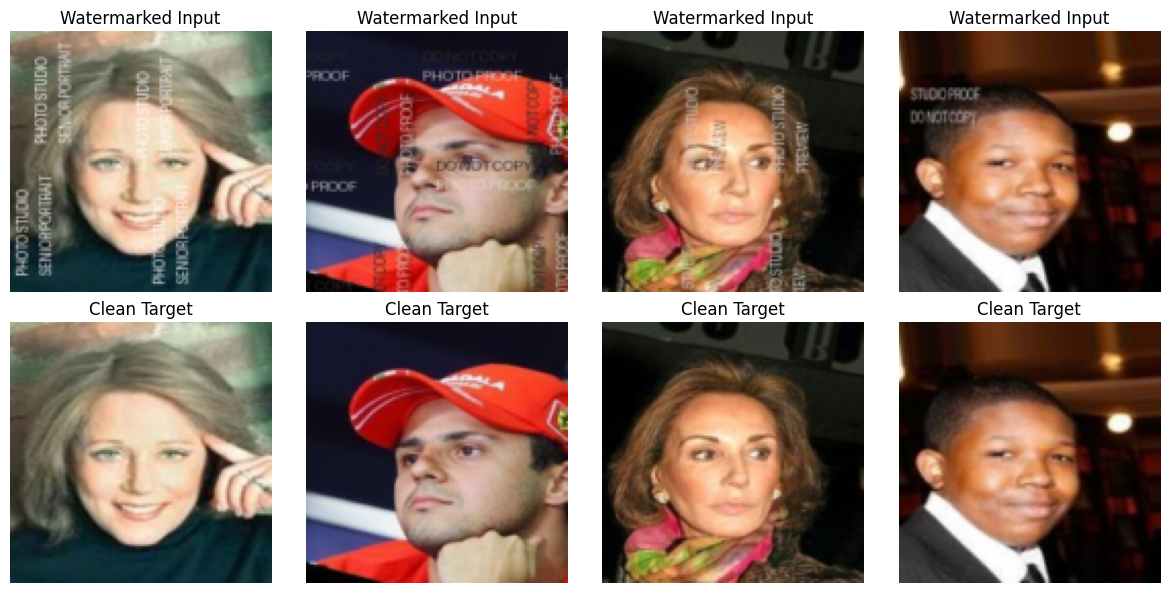

In [9]:
def show_samples(dataloader, num_samples=4):
    watermarked, clean = next(iter(dataloader))

    plt.figure(figsize=(12, 6))

    for i in range(num_samples):
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(watermarked[i].permute(1, 2, 0))
        plt.title("Watermarked Input")
        plt.axis("off")

        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(clean[i].permute(1, 2, 0))
        plt.title("Clean Target")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(dataloader)

In [15]:
os.makedirs("samples", exist_ok=True)

watermarked, clean = next(iter(dataloader))

for i in range(5):
    wm_img = transforms.ToPILImage()(watermarked[i])
    clean_img = transforms.ToPILImage()(clean[i])

    wm_img.save(f"samples/watermarked_{i}.png")
    clean_img.save(f"samples/clean_{i}.png")

print("Saved sample images in the samples folder.")

Saved sample images in the samples folder.


In [18]:
watermarked_batch, clean_batch = next(iter(dataloader))

print("Watermarked batch shape:", watermarked_batch.shape)
print("Clean batch shape:", clean_batch.shape)
print("Pixel range:", watermarked_batch.min().item(), "to", watermarked_batch.max().item())

Watermarked batch shape: torch.Size([16, 3, 128, 128])
Clean batch shape: torch.Size([16, 3, 128, 128])
Pixel range: 0.0 to 1.0
